<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/R/R_Clustering_ARL_ReinfLearn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

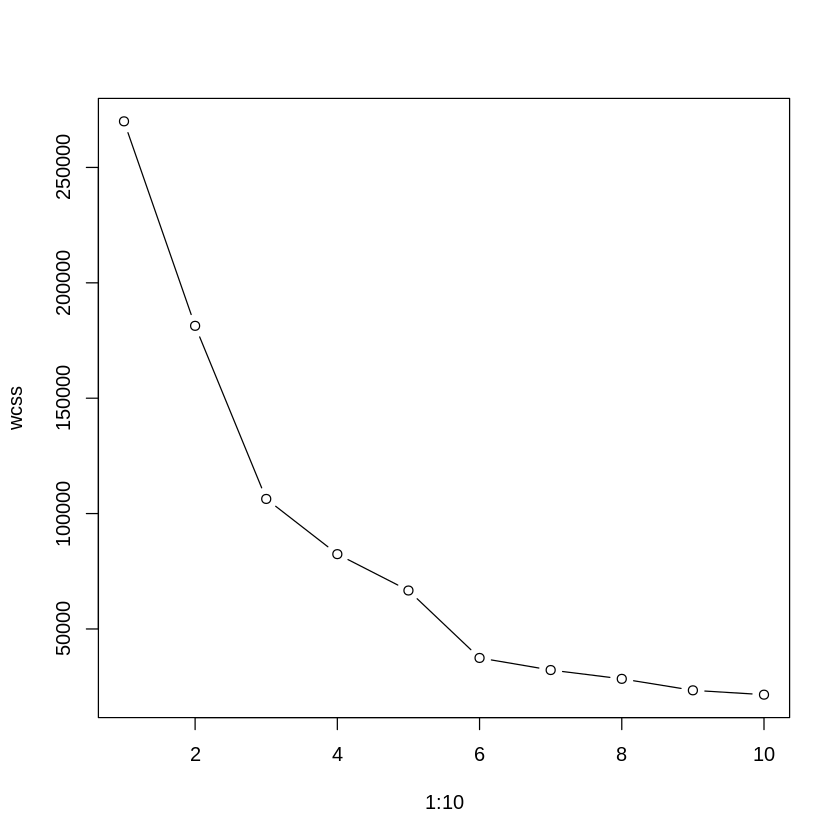

In [ ]:
# k means clustering

data <- read.csv("mall.csv")
X <- data[4:5]

wcss <- vector()
for (i in 1:10) wcss[i] <- sum(kmeans(X, i)$tot.withinss)

plot(1:10, wcss, type = "b")

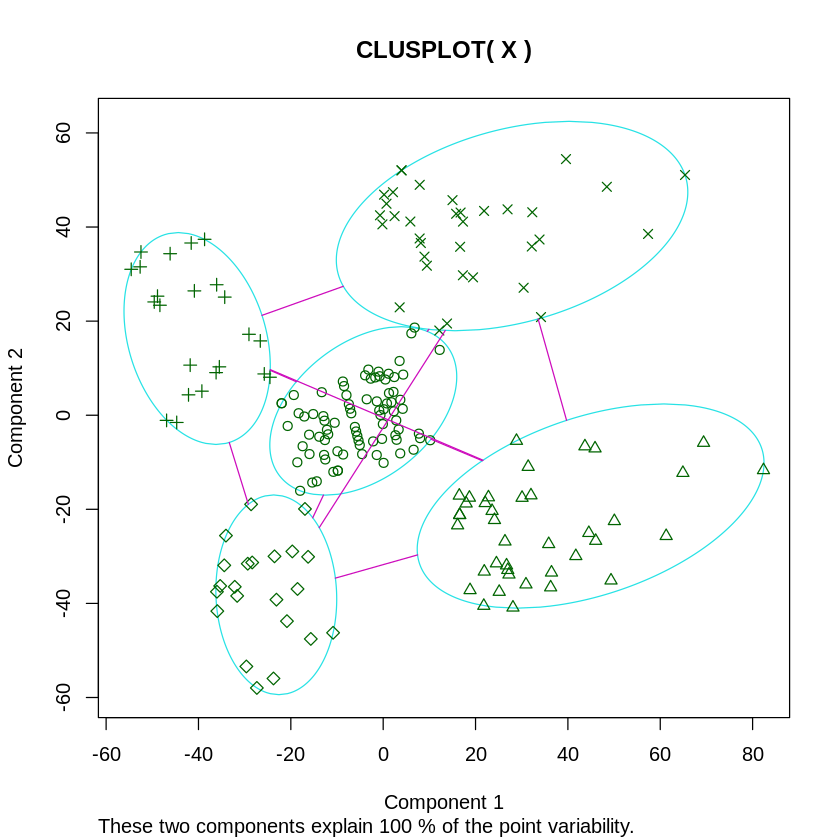

In [ ]:
kmeans = kmeans(X, 5)
library(cluster)
clusplot(X, kmeans$cluster)

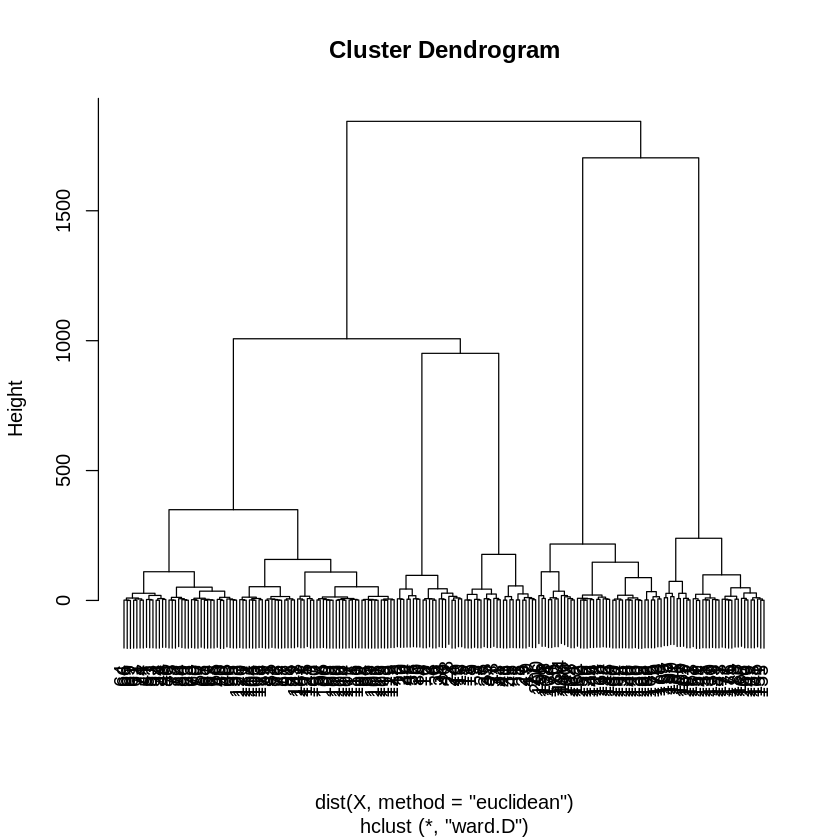

In [ ]:
# hierarchical clustering

dendrogram = hclust(dist(X, method="euclidean"), method="ward.D")
plot(dendrogram)

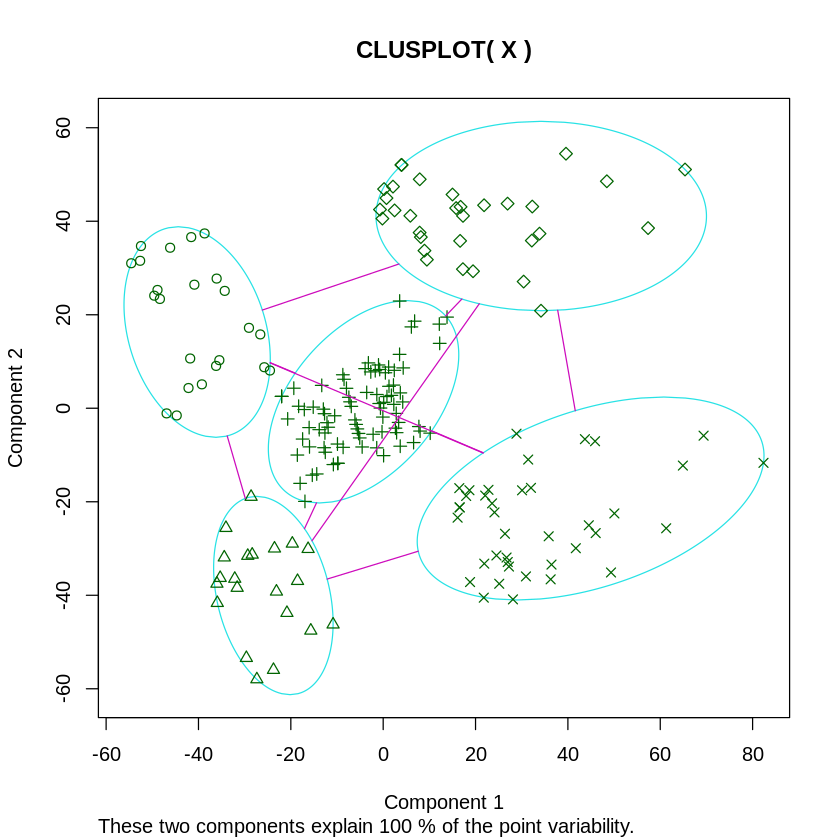

In [ ]:
hc = hclust(dist(X, method="euclidean"), method="ward.D")
y_hc = cutree(hc, 5)
clusplot(X, y_hc)

Loading required package: Matrix


Attaching package: ‘arules’


The following objects are masked from ‘package:base’:

    abbreviate, write




distribution of transactions with duplicates:
1 
5 


transactions as itemMatrix in sparse format with
 7501 rows (elements/itemsets/transactions) and
 119 columns (items) and a density of 0.03288973 

most frequent items:
mineral water          eggs     spaghetti  french fries     chocolate 
         1788          1348          1306          1282          1229 
      (Other) 
        22405 

element (itemset/transaction) length distribution:
sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
1754 1358 1044  816  667  493  391  324  259  139  102   67   40   22   17    4 
  18   19   20 
   1    2    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   3.914   5.000  20.000 

includes extended item information - examples:
             labels
1           almonds
2 antioxydant juice
3         asparagus

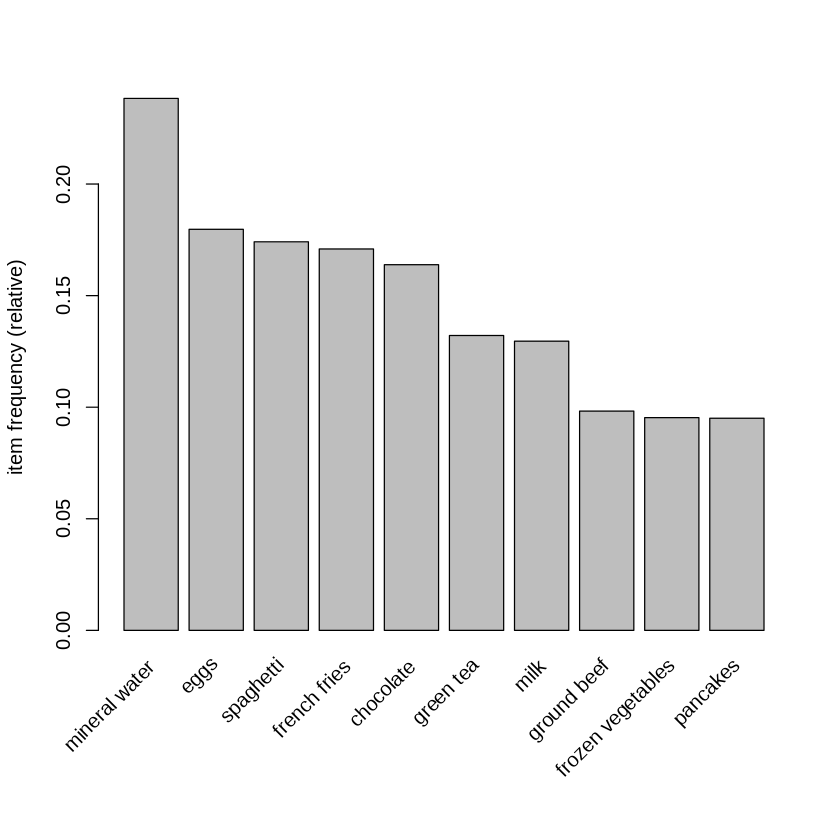

In [ ]:
# apriori

data = read.csv("market_basket.csv", header=FALSE)

# install.packages("arules")
library(arules)

data = read.transactions("market_basket.csv", sep=",", rm.duplicates=TRUE)

summary(data)

itemFrequencyPlot(data, topN=10)

In [ ]:
rules = apriori(data=data,
  parameter=list(support=0.004, confidence=0.2))

inspect(sort(rules, by="lift")[1:10])

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.2    0.1    1 none FALSE            TRUE       5   0.004      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 30 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[119 item(s), 7501 transaction(s)] done [0.01s].
sorting and recoding items ... [114 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 done [0.00s].
writing ... [811 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
     lhs                       rhs                 support confidence   coverage     lift count
[1]  {light cream}          => {chicken}       0.004532729  0.2905983 0.01559792 4.843951    34
[2]  {pasta}                => {escalope}      0.005865885  0.3728814 0.01573124 4.700812    

In [ ]:
# eclat

rules = eclat(data=data,
  parameter=list(support=0.004))

inspect(sort(rules, by="support")[1:10])

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   0.004      1     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 30 

create itemset ... 
set transactions ...[119 item(s), 7501 transaction(s)] done [0.01s].
sorting and recoding items ... [114 item(s)] done [0.00s].
creating sparse bit matrix ... [114 row(s), 7501 column(s)] done [0.00s].
writing  ... [959 set(s)] done [0.02s].
Creating S4 object  ... done [0.00s].
     items               support    count
[1]  {mineral water}     0.23836822 1788 
[2]  {eggs}              0.17970937 1348 
[3]  {spaghetti}         0.17411012 1306 
[4]  {french fries}      0.17091055 1282 
[5]  {chocolate}         0.16384482 1229 
[6]  {green tea}         0.13211572  991 
[7]  {milk}              0.12958272  972 
[8]  {ground beef}       0.09825357  737 
[9]  {frozen vegetables} 0.09532062  715 
[10] {pancakes}          0.09505399 

In [ ]:
# eclat

rules = eclat(data=data,
  parameter=list(support=0.004, minlen=2))

inspect(sort(rules, by="support")[1:10])

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   0.004      2     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 30 

create itemset ... 
set transactions ...[119 item(s), 7501 transaction(s)] done [0.01s].
sorting and recoding items ... [114 item(s)] done [0.00s].
creating sparse bit matrix ... [114 row(s), 7501 column(s)] done [0.00s].
writing  ... [845 set(s)] done [0.02s].
Creating S4 object  ... done [0.00s].
     items                              support    count
[1]  {mineral water, spaghetti}         0.05972537 448  
[2]  {chocolate, mineral water}         0.05265965 395  
[3]  {eggs, mineral water}              0.05092654 382  
[4]  {milk, mineral water}              0.04799360 360  
[5]  {ground beef, mineral water}       0.04092788 307  
[6]  {ground beef, spaghetti}           0.03919477 294  
[7]  {chocolate, spaghetti}             0.03919477 294  


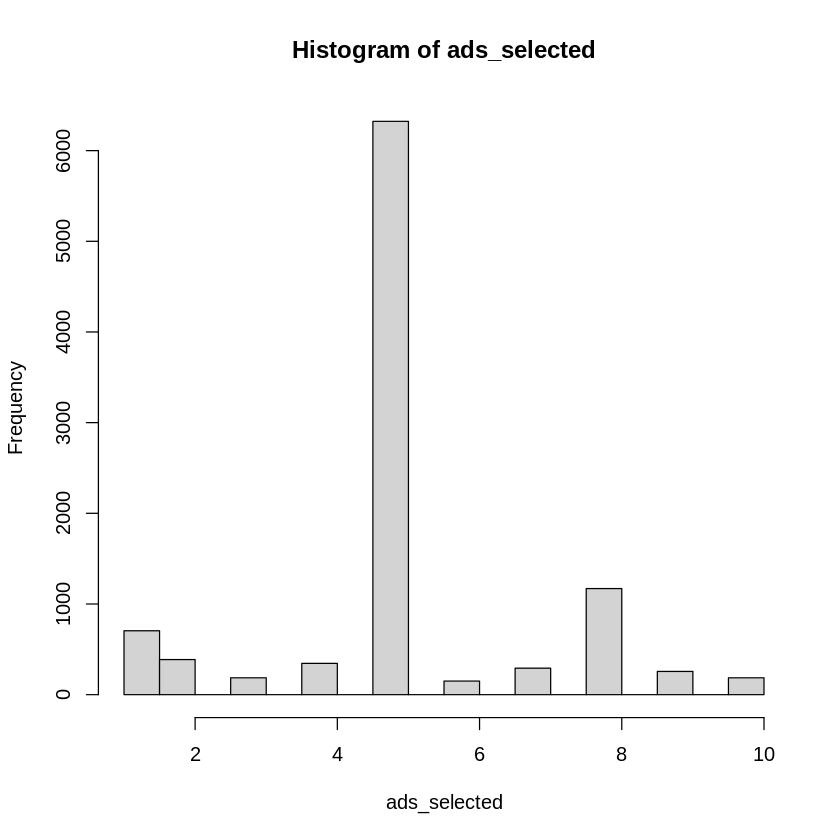

In [ ]:
# ucb upper confidence bound

data = read.csv("ads_2.csv")

N = 10000
d = 10
ads_selected = integer(0)
numbers_of_selections = integer(d)
sums_of_rewards = integer(d)
total_reward = 0

for (n in 1:N) {
  ad = 0
  max_upper_bound = 0

  for (i in 1:d) {
    if (numbers_of_selections[i] > 0){
      average_reward = sums_of_rewards[i] / numbers_of_selections[i]
      delta_i = sqrt(3/2 * log(n) / numbers_of_selections[i])
      upper_bound = average_reward + delta_i
    } else {
      upper_bound = 1e400
    }
    if (upper_bound > max_upper_bound) {
        max_upper_bound = upper_bound
        ad = i
    }
  }
  ads_selected = append(ads_selected, ad)
  numbers_of_selections[ad] = numbers_of_selections[ad] + 1
  reward = data[n, ad]
  sums_of_rewards[ad] = sums_of_rewards[ad] + reward
  total_reward = total_reward + reward
}

hist(ads_selected)

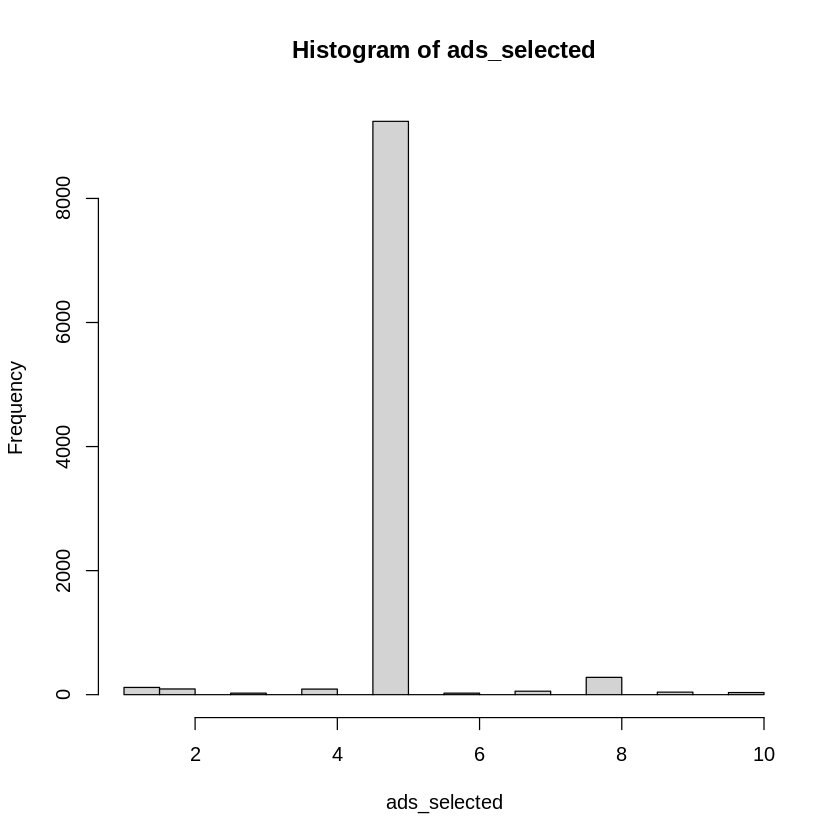

In [ ]:
# thompson

N = 10000
d = 10
ads_selected = integer(0)
numbers_of_rewards_1 = integer(d)
numbers_of_rewards_0 = integer(d)
total_reward = 0

for (n in 1:N) {
  ad = 0
  max_random = 0

  for (i in 1:d) {
    random_beta = rbeta(n=1,
    shape1 = numbers_of_rewards_1[i] + 1,
    shape2 = numbers_of_rewards_0[i] + 1)
    if (random_beta > max_random) {
      max_random = random_beta
      ad = i
    }
  }
  ads_selected = append(ads_selected, ad)
  reward = data[n, ad]

  if (reward == 1) {
    numbers_of_rewards_1[ad] = numbers_of_rewards_1[ad] + 1
  } else {
    numbers_of_rewards_0[ad] = numbers_of_rewards_0[ad] + 1
  }

  total_reward = total_reward + reward
}

hist(ads_selected)